# BREAST CANCER MASSES DATASET (DATASET 2 ) PIPELINE 

import all required libraries including TensorFlow, sklearn, matplotlib, and model layers needed for training and evaluation
and the filesystem paths for the benign and malignant mammography datasets stored in Kaggle.

In [ ]:
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization



from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, Input
from tensorflow.keras.models import Model


benign_path = "//kaggle/input/breastcancermasses/Dataset of Mammography with Benign Malignant Breast Masses/Dataset of Mammography with Benign Malignant Breast Masses/INbreast+MIAS+DDSM Dataset/Benign Masses"
malignant_path = "/kaggle/input/breastcancermasses/Dataset of Mammography with Benign Malignant Breast Masses/Dataset of Mammography with Benign Malignant Breast Masses/INbreast+MIAS+DDSM Dataset/Malignant Masses"






read all image paths from benign/malignant folders and assigns labels (0=benign, 1=malignant).

In [ ]:
def get_file_paths_and_labels(directory, label):
    file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith((".png", ".jpg", ".jpeg"))]
    labels = [label] * len(file_paths)
    return file_paths, labels


In [ ]:
benign_file_paths, benign_labels = get_file_paths_and_labels(benign_path, 0)
malignant_file_paths, malignant_labels = get_file_paths_and_labels(malignant_path, 1)

In [ ]:
file_paths = benign_file_paths + malignant_file_paths
labels = benign_labels + malignant_labels



split the dataset into train, validation, and test sets while preserving class balance using stratify

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(file_paths, labels, test_size=0.2, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)



convert Python lists to NumPy arrays for faster

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split



X_train = np.array(X_train)
y_train = np.array(y_train)

X_val   = np.array(X_val)
y_val   = np.array(y_val)

X_test  = np.array(X_test)
y_test  = np.array(y_test)

print("Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (19660,)
y_train: (19660,)
X_val: (2458,)
y_val: (2458,)
X_test: (2458,)
y_test: (2458,)


defining and applying augumentation and  the CBC (contrast/brightness correction) filter to the training images, and loads validation/test images.

In [ ]:
import numpy as np
import cv2
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def apply_CBC(image, alpha=1.0, beta=0):
    """Apply CBC filter (contrast/brightness)"""
    if isinstance(image, str):
        image = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from path: {image}")

    if not isinstance(image, np.ndarray):
        image = np.array(image)

    if image.dtype != np.uint8:
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    img_cbc = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
    img_cbc = cv2.resize(img_cbc, (224, 224))
    return img_cbc

print("Applying CBC filter to training data...")
X_train_filtered = np.array([apply_CBC(img, alpha=1.0, beta=0) for img in X_train], dtype='float32')
print(f"Shape after CBC filter: {X_train_filtered.shape}")

X_train_filtered = X_train_filtered.reshape(X_train_filtered.shape[0], 224, 224, 1)
print(f"Shape after reshape: {X_train_filtered.shape}")

print("\nLoading validation data...")
X_val_array = []
for img_path in X_val:
    if isinstance(img_path, str):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    else:
        img = img_path
    img = cv2.resize(img, (224, 224))
    X_val_array.append(img)
X_val_array = np.array(X_val_array, dtype='float32').reshape(-1, 224, 224, 1)
print(f"X_val shape: {X_val_array.shape}")

print("\nLoading test data...")
X_test_array = []
for img_path in X_test:
    if isinstance(img_path, str):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    else:
        img = img_path
    img = cv2.resize(img, (224, 224))
    X_test_array.append(img)
X_test_array = np.array(X_test_array, dtype='float32').reshape(-1, 224, 224, 1)
print(f"X_test shape: {X_test_array.shape}")

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow(X_train_filtered, y_train, batch_size=32, shuffle=True)
val_generator   = val_test_datagen.flow(X_val_array, y_val, batch_size=32, shuffle=False)
test_generator  = val_test_datagen.flow(X_test_array, y_test, batch_size=32, shuffle=False)



Applying CBC filter to training data...
Shape after CBC filter: (19660, 224, 224)
Shape after reshape: (19660, 224, 224, 1)

Loading validation data...
X_val shape: (2458, 224, 224, 1)

Loading test data...
X_test shape: (2458, 224, 224, 1)


showing sample benign and malignant images before vs after applying CBC enhancement

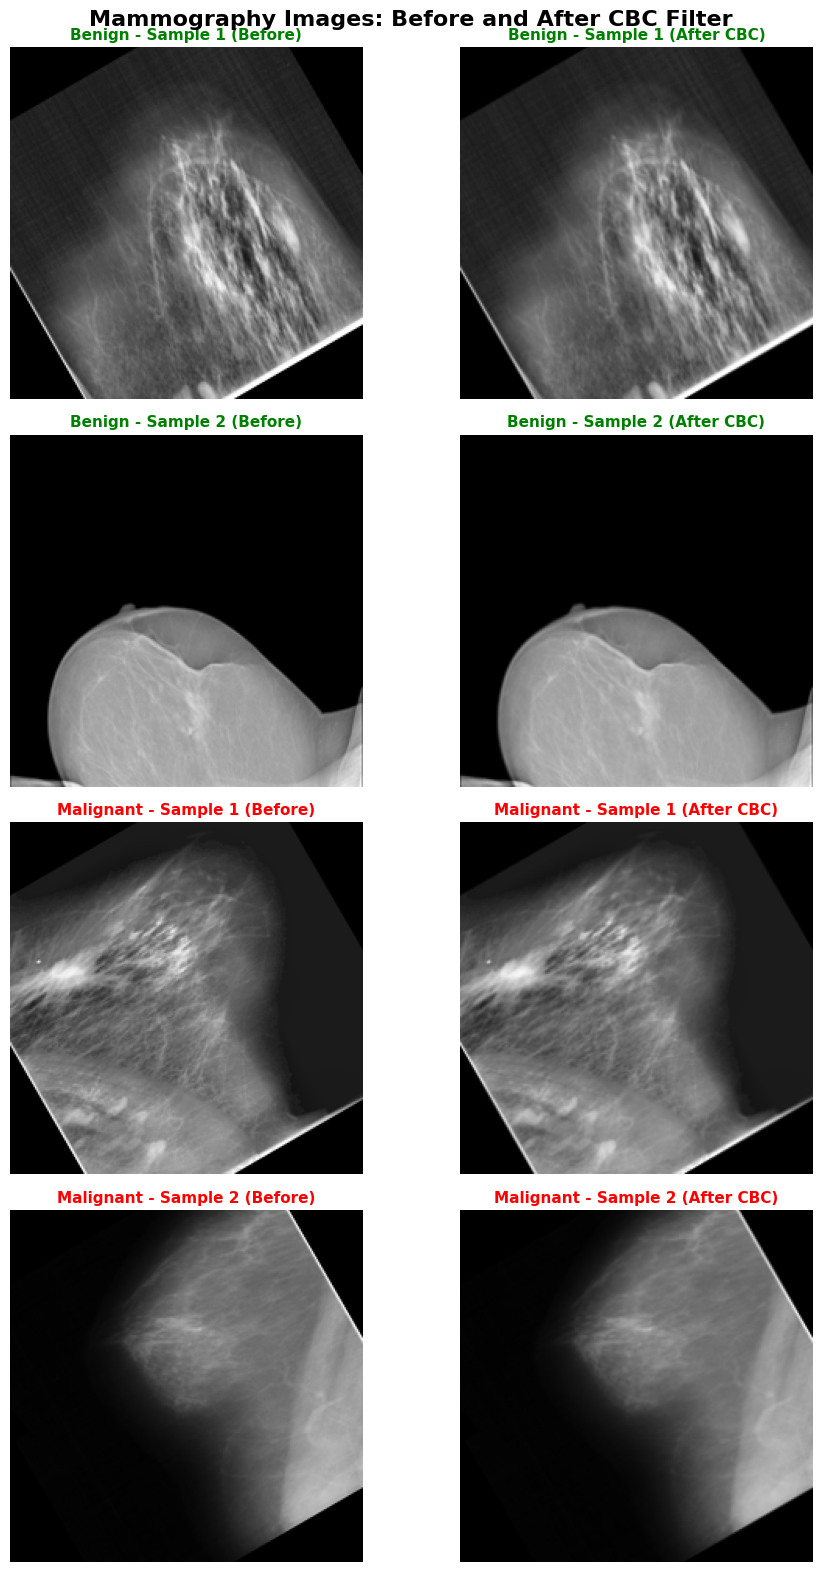


Class Distribution:
Benign (0): 8692 samples
Malignant (1): 10968 samples


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

benign_indices = np.where(y_train == 0)[0]
malignant_indices = np.where(y_train == 1)[0]

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle('Mammography Images: Before and After CBC Filter', fontsize=16, fontweight='bold')

idx = benign_indices[0]
img_before = cv2.imread(X_train[idx], cv2.IMREAD_GRAYSCALE)
axes[0, 0].imshow(img_before, cmap='gray')
axes[0, 0].set_title('Benign - Sample 1 (Before)', fontsize=11, color='green', fontweight='bold')
axes[0, 0].axis('off')
axes[0, 1].imshow(X_train_filtered[idx], cmap='gray')
axes[0, 1].set_title('Benign - Sample 1 (After CBC)', fontsize=11, color='green', fontweight='bold')
axes[0, 1].axis('off')

idx = benign_indices[1]
img_before = cv2.imread(X_train[idx], cv2.IMREAD_GRAYSCALE)
axes[1, 0].imshow(img_before, cmap='gray')
axes[1, 0].set_title('Benign - Sample 2 (Before)', fontsize=11, color='green', fontweight='bold')
axes[1, 0].axis('off')
axes[1, 1].imshow(X_train_filtered[idx], cmap='gray')
axes[1, 1].set_title('Benign - Sample 2 (After CBC)', fontsize=11, color='green', fontweight='bold')
axes[1, 1].axis('off')

idx = malignant_indices[0]
img_before = cv2.imread(X_train[idx], cv2.IMREAD_GRAYSCALE)
axes[2, 0].imshow(img_before, cmap='gray')
axes[2, 0].set_title('Malignant - Sample 1 (Before)', fontsize=11, color='red', fontweight='bold')
axes[2, 0].axis('off')
axes[2, 1].imshow(X_train_filtered[idx], cmap='gray')
axes[2, 1].set_title('Malignant - Sample 1 (After CBC)', fontsize=11, color='red', fontweight='bold')
axes[2, 1].axis('off')

idx = malignant_indices[1]
img_before = cv2.imread(X_train[idx], cv2.IMREAD_GRAYSCALE)
axes[3, 0].imshow(img_before, cmap='gray')
axes[3, 0].set_title('Malignant - Sample 2 (Before)', fontsize=11, color='red', fontweight='bold')
axes[3, 0].axis('off')
axes[3, 1].imshow(X_train_filtered[idx], cmap='gray')
axes[3, 1].set_title('Malignant - Sample 2 (After CBC)', fontsize=11, color='red', fontweight='bold')
axes[3, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nClass Distribution:")
print(f"Benign (0): {len(benign_indices)} samples")
print(f"Malignant (1): {len(malignant_indices)} samples")

build a ResNet50V2 model adapted for grayscale (1-channel) inputs.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def build_resnet_grayscale_binary():
    inputs = Input(shape=(224,224,1))
    x = Conv2D(3, (3,3), padding='same', activation='linear')(inputs)


    base_model = tf.keras.applications.ResNet50V2(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

model = build_resnet_grayscale_binary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

model.summary()


I0000 00:00:1763187426.602604      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763187426.603523      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,105,887 (91.96 MB)

 Trainable params: 541,087 (2.06 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

extract all generator batches into NumPy arrays

In [ ]:
import numpy as np

def generator_to_numpy(gen):
    X = []
    y = []

    for i in range(len(gen)):
        batch_x, batch_y = gen[i]
        X.append(batch_x)
        y.append(batch_y)

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)

    return X, y

X_train, y_train = generator_to_numpy(train_generator)
X_val, y_val = generator_to_numpy(val_generator)
X_test, y_test = generator_to_numpy(test_generator)

print("Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Shapes:
X_train: (19660, 224, 224, 1)
y_train: (19660,)
X_val: (2458, 224, 224, 1)
y_val: (2458,)
X_test: (2458, 224, 224, 1)
y_test: (2458,)


setting EarlyStopping, ReduceLROnPlateau, Checkpoint and trains the model.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import pickle

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights: {class_weight_dict}")

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,
    min_lr=1e-7,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='/kaggle/working/Mammography_CBC_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1,
    save_weights_only=False)

print("\n" + "="*50)
print("Starting Training...")
print("="*50)

history = model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    callbacks=[reduce_lr, early_stopping, checkpoint],
    verbose=1,
    class_weight=class_weight_dict
)

print("\n✓ Best model saved at: /kaggle/working/Mammography_CBC_best_model.keras")

with open('/kaggle/working/Mammography_CBC_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("✓ Training history saved!")





Class weights: {0: 1.130924988495168, 1: 0.8962436177972283}

Starting Training...
Epoch 1/100


I0000 00:00:1763187516.856009     117 service.cc:148] XLA service 0x7d95700a4ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763187516.856724     117 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763187516.856744     117 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763187518.434087     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.6087 - auc: 0.6568 - loss: 0.6538
Epoch 1: val_loss improved from inf to 0.41635, saving model to /kaggle/working/Mammography_CBC_best_model.keras
615/615 ━━━━━━━━━━━━━━━━━━━━ 130s 180ms/step - accuracy: 0.6088 - auc: 0.6570 - loss: 0.6537 - val_accuracy: 0.8157 - val_auc: 0.9031 - val_loss: 0.4163 - learning_rate: 3.0000e-04
Epoch 2/100
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7644 - auc: 0.8457 - loss: 0.4828
Epoch 2: val_loss improved from 0.41635 to 0.33467, saving model to /kaggle/working/Mammography_CBC_best_model.keras
615/615 ━━━━━━━━━━━━━━━━━━━━ 102s 165ms/step - accuracy: 0.7644 - auc: 0.8458 - loss: 0.4827 - val_accuracy: 0.8527 - val_auc: 0.9360 - val_loss: 0.3347 - learning_rate: 3.0000e-04
Epoch 3/100
615/615 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8073 - auc: 0.8914 - loss: 0.4125
Epoch 3: val_loss did not improve from 0.33467
615/615 ━━━━━━━━━━━━━━━━━━━━ 102s 165ms/step - accuracy: 0.8073 

Plotting accuracy, loss, AUC curves for both training and validation.

Metrics saved: dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss', 'learning_rate'])


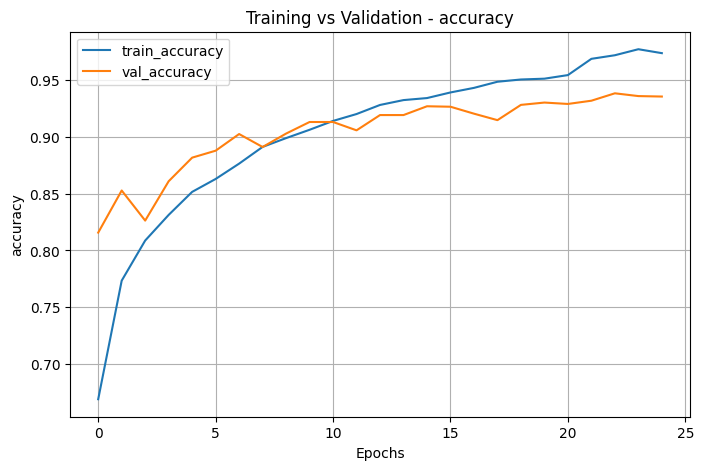

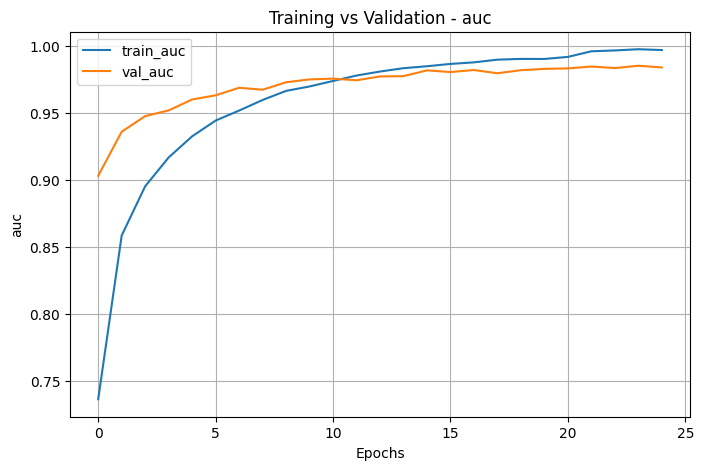

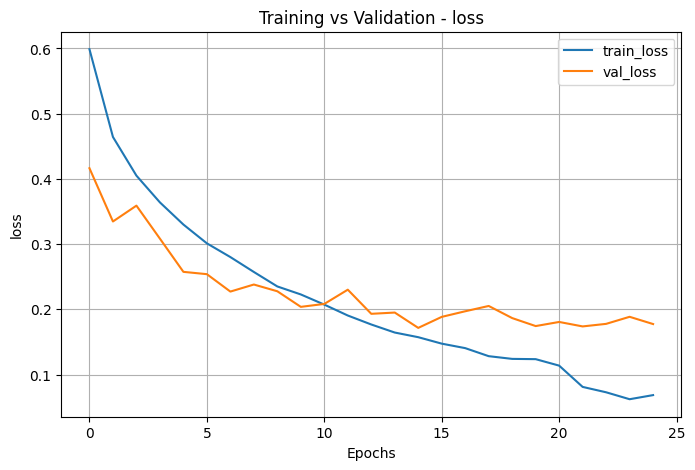

In [ ]:
import pickle
import matplotlib.pyplot as plt

with open("/kaggle/working/Mammography_CBC_history.pkl", "rb") as f:
    history = pickle.load(f)

print("Metrics saved:", history.keys())

exclude = ["f1", "learning_rate"]

metrics = [
    m for m in history.keys()
    if not m.startswith("val_") and not any(ex in m.lower() for ex in exclude)
]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    plt.plot(history[metric], label=f"train_{metric}")

    val_metric = f"val_{metric}"
    if val_metric in history:
        plt.plot(history[val_metric], label=f"val_{metric}")

    plt.title(f"Training vs Validation - {metric}")
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()


reloading the trained model and adds the custom F1 score.

In [ ]:
import tensorflow as tf

def f1_score_binary(y_true, y_pred):
    y_pred = tf.round(y_pred)
    tp = tf.reduce_sum(tf.cast(y_true * y_pred, 'float32'))
    fp = tf.reduce_sum(tf.cast((1 - y_true) * y_pred, 'float32'))
    fn = tf.reduce_sum(tf.cast(y_true * (1 - y_pred), 'float32'))
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    return 2 * precision * recall / (precision + recall + 1e-7)

best_model = tf.keras.models.load_model(
    "/kaggle/working/Mammography_CBC_best_model.keras",
    custom_objects={"f1_score_binary": f1_score_binary}
)


predicting on test data and prints classification metrics.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

y_pred_proba = best_model.predict(test_generator, verbose=1)

if y_pred_proba.shape[1] > 1:
    y_pred = np.argmax(y_pred_proba, axis=1)
else:
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()

if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred, average='binary'))
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))


77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step
Accuracy: 0.9247355573637104
F1 Score: 0.9328493647912887

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      1087
           1       0.93      0.94      0.93      1371

    accuracy                           0.92      2458
   macro avg       0.92      0.92      0.92      2458
weighted avg       0.92      0.92      0.92      2458


Confusion Matrix:
 [[ 988   99]
 [  86 1285]]


compute and visualize the confusion matrix using Seaborn.

77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step
Confusion Matrix:
 [[ 988   99]
 [  86 1285]]


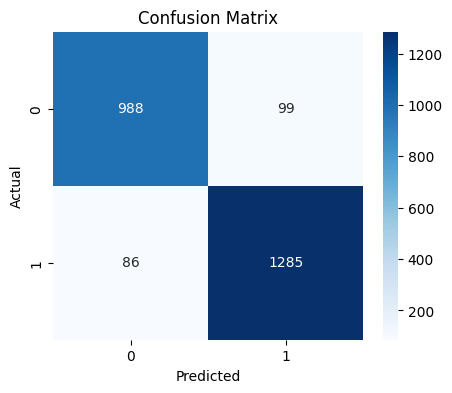

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_proba = best_model.predict(test_generator, verbose=1)

if y_pred_proba.shape[1] > 1:
    y_pred = np.argmax(y_pred_proba, axis=1)
else:
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()


if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test


cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


visualize a few real images with their predicted and actual labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


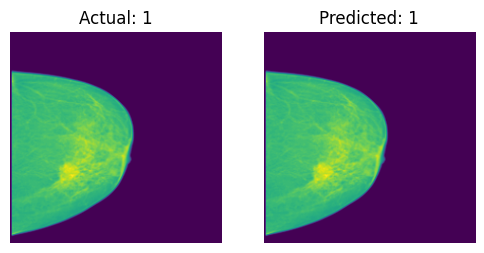

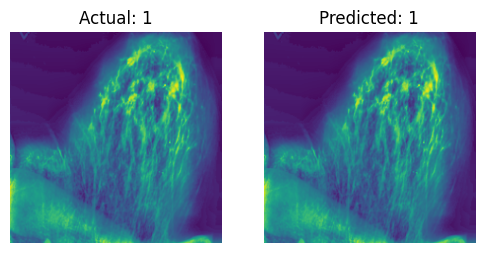

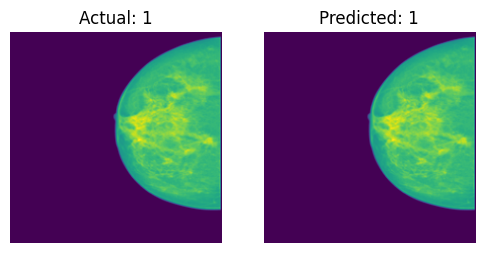

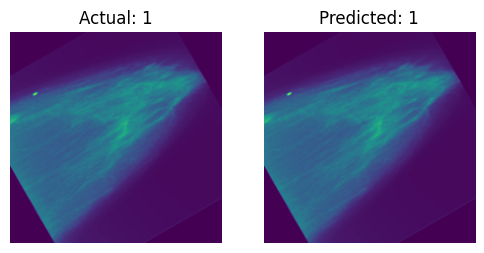

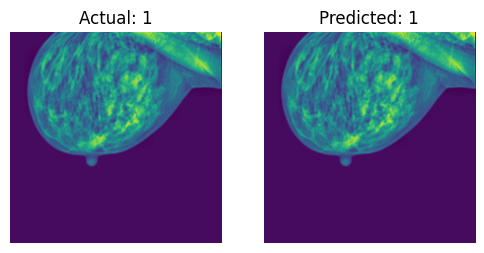

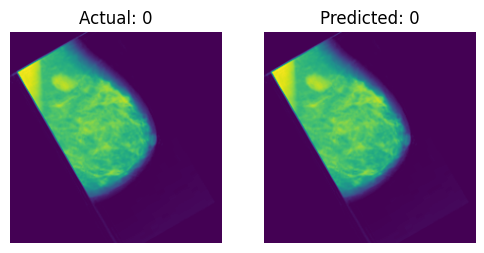

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


num_samples = 6

x_batch, y_batch = next(test_generator)


y_pred_batch_proba = best_model.predict(x_batch)
if y_pred_batch_proba.shape[1] > 1:
    y_pred_batch = np.argmax(y_pred_batch_proba, axis=1)
    y_true_batch = np.argmax(y_batch, axis=1)
else:
    y_pred_batch = (y_pred_batch_proba > 0.5).astype(int).flatten()
    y_true_batch = y_batch


for i in range(num_samples):
    plt.figure(figsize=(6, 3))


    plt.subplot(1, 2, 1)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(f"Actual: {y_true_batch[i]}")


    plt.subplot(1, 2, 2)
    plt.imshow(x_batch[i])
    plt.axis('off')
    plt.title(f"Predicted: {y_pred_batch[i]}")

    plt.show()


plot the ROC curve and computes AUC score.

77/77 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step


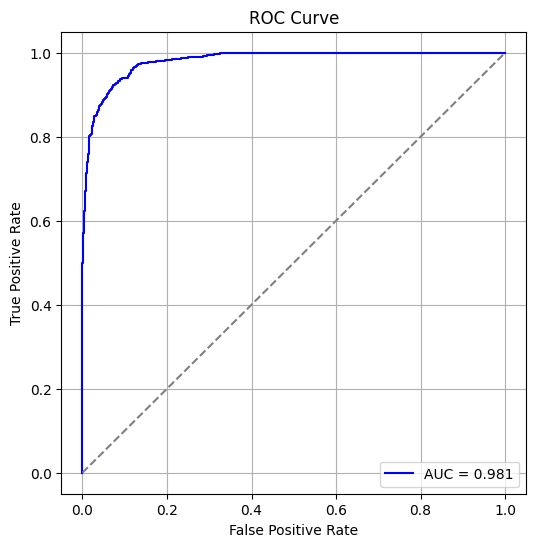

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np


y_pred_proba = best_model.predict(test_generator, verbose=1)

if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)

    from sklearn.preprocessing import label_binarize
    y_true_bin = label_binarize(y_true, classes=np.arange(y_pred_proba.shape[1]))
else:
    y_true_bin = y_test


if y_pred_proba.shape[1] > 1:
    y_score = y_pred_proba[:, 1]
else:
    y_score = y_pred_proba.flatten()

fpr, tpr, thresholds = roc_curve(y_true_bin, y_score)
auc_score = roc_auc_score(y_true_bin, y_score)


plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
